Step 1: Import Libraries

We begin by importing the necessary tools: TensorFlow/Keras for building models, Matplotlib for plotting, NumPy for numerical operations, and Scikit-Learn for evaluation metrics.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

Step 2: Load and Explore Dataset

Load the MNIST dataset, which contains 60,000 training images and 10,000 test images of handwritten digits (0-9).
Examine the shape of the data arrays (images and labels).
Display a few sample images with their corresponding labels.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
--- Dataset Shapes ---
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

--- Sample Images ---


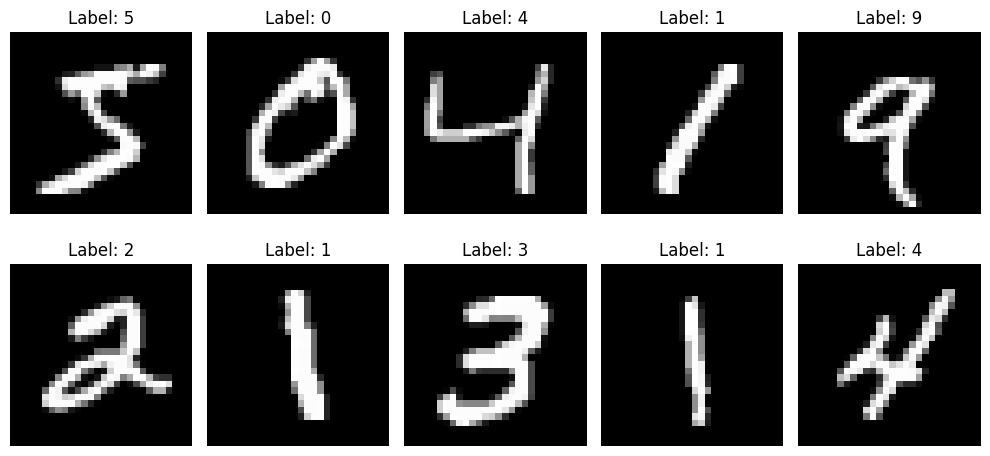

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("--- Dataset Shapes ---")
print("Training images shape:", X_train.shape) # Output: (60000, 28, 28) -> 60k images, 28x28 pixels each
print("Training labels shape:", y_train.shape) # Output: (60000,) -> 60k labels
print("Test images shape:", X_test.shape)     # Output: (10000, 28, 28)
print("Test labels shape:", y_test.shape)     # Output: (10000,)

print("\n--- Sample Images ---")
plt.figure(figsize=(10, 5))
for i in range(10): # Display first 10 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray') # Display in grayscale
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

Step 3: Preprocess Data

Normalization: Neural networks generally perform better when input data is scaled. We normalize the pixel values from the range [0, 255] to [0, 1] by dividing by 255.0.
Label Reshaping: Ensure labels are 1D arrays (this is usually the default for mnist.load_data but good practice to confirm).


In [3]:
print("\n--- Preprocessing ---")
# Check label shapes before potentially reshaping (optional, usually okay for MNIST)
print("Original y_train shape:", y_train.shape)
y_train = y_train.reshape(-1,) # Ensure y_train is a 1D array
y_test = y_test.reshape(-1,)   # Ensure y_test is a 1D array
print("Reshaped y_train shape:", y_train.shape)

# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Data normalized.")


--- Preprocessing ---
Original y_train shape: (60000,)
Reshaped y_train shape: (60000,)
Data normalized.


Step 4: Build and Train a Simple ANN Model

We first build a basic ANN using Flatten to convert the 28x28 images into a 1D vector (784 elements) and Dense (fully connected) layers for classification.

In [4]:
print("\n--- Building ANN Model ---")
ann = models.Sequential([
    # Flatten the 28x28 image into a 1D vector of 784 pixels
    layers.Flatten(input_shape=(28, 28)),

    # Dense hidden layer with 128 neurons and ReLU activation
    layers.Dense(128, activation='relu'),

    # Output layer with 10 neurons (one for each digit 0-9)
    # Softmax activation outputs probabilities for each class
    layers.Dense(10, activation='softmax')
])

# Compile the model: configure optimizer, loss function, and metrics
ann.compile(optimizer='adam',                     # Adam optimizer is generally a good default
            loss='sparse_categorical_crossentropy', # Use for integer labels (0, 1, ... 9)
            metrics=['accuracy'])                 # Track accuracy during training

ann.summary() # Print model architecture

print("\n--- Training ANN Model ---")
# Train the model for 5 epochs (passes through the entire training dataset)
history_ann = ann.fit(X_train, y_train, epochs=5, validation_split=0.1) # Use 10% of training data for validation


--- Building ANN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Training ANN Model ---
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9205 - loss: 0.2762 - val_accuracy: 0.9688 - val_loss: 0.1174
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9644 - loss: 0.1205 - val_accuracy: 0.9735 - val_loss: 0.0988
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9749 - loss: 0.0828 - val_accuracy: 0.9775 - val_loss: 0.0784
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0614 - val_accuracy: 0.9773 - val_loss: 0.0778
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9858 - loss: 0.0469 - val_accuracy: 0.9777 - val_loss: 0.0708


Step 5: Evaluate the ANN Model

Assess the trained ANN's performance on the unseen test data.
Generate a classification report (showing precision, recall, F1-score per class) and a confusion matrix (visualizing correct vs. incorrect predictions).



--- Evaluating ANN Model ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0822
ANN Test Accuracy: 0.9744
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (ANN):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.95      0.98      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.95      0.98      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000


Confusion Matrix (ANN):


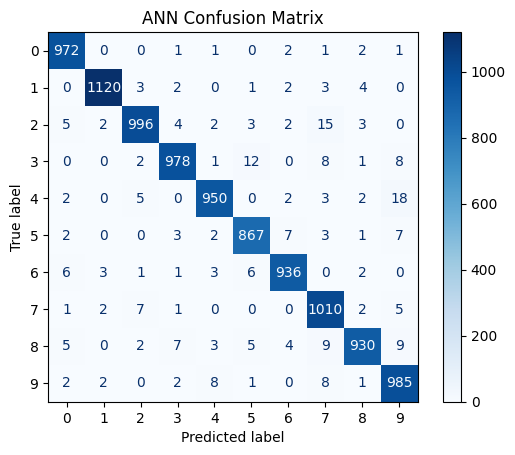

In [5]:
print("\n--- Evaluating ANN Model ---")
loss_ann, accuracy_ann = ann.evaluate(X_test, y_test)
print(f"ANN Test Accuracy: {accuracy_ann:.4f}")

# Make predictions on the test set
y_pred_ann_prob = ann.predict(X_test)
# Convert probabilities to predicted class labels (index of the max probability)
y_pred_ann_classes = np.argmax(y_pred_ann_prob, axis=1)

# Print Classification Report
print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann_classes))

# Display Confusion Matrix
print("\nConfusion Matrix (ANN):")
cm_ann = confusion_matrix(y_test, y_pred_ann_classes)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann)
disp_ann.plot(cmap=plt.cm.Blues)
plt.title("ANN Confusion Matrix")
plt.show()

Step 6: Build and Train a CNN Model

Now, build a CNN using Conv2D and MaxPooling2D layers to automatically extract spatial features before flattening and classifying with Dense layers.
Important: Keras Conv2D layers expect input data with a channel dimension. Since MNIST is grayscale, we reshape the (28, 28) images to (28, 28, 1).


In [6]:
print("\n--- Building CNN Model ---")
cnn = models.Sequential([
    # First Convolutional Layer: Learns 32 basic features (like edges, corners)
    # kernel_size=(3,3): Uses a 3x3 filter window
    # activation='relu': Standard activation for non-linearity
    # input_shape=(28, 28, 1): MNIST image dimensions (Height, Width, Channels=1 for grayscale)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # Pooling Layer: Reduces size by half (2x2 window), keeps strongest activations
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer: Learns 64 more complex features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Another pooling layer

    # Flatten Layer: Converts the 2D feature maps into a 1D vector
    layers.Flatten(),

    # Dense Layer: A fully connected layer for combining features
    layers.Dense(64, activation='relu'),

    # Output Layer: 10 neurons (one for each digit 0-9), softmax for probabilities
    layers.Dense(10, activation='softmax')
])

# Compile the CNN model
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary() # Print CNN architecture

# Reshape input data for CNN (add channel dimension)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
print("\nReshaped training data for CNN:", X_train_cnn.shape)

print("\n--- Training CNN Model ---")
# Train the CNN model (fewer epochs often needed than ANN for good performance)
history_cnn = cnn.fit(X_train_cnn, y_train, epochs=3, validation_split=0.1)


--- Building CNN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Reshaped training data for CNN: (60000, 28, 28, 1)

--- Training CNN Model ---
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9537 - loss: 0.1522 - val_accuracy: 0.9853 - val_loss: 0.0452
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9848 - loss: 0.0476 - val_accuracy: 0.9857 - val_loss: 0.0473
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9899 - loss: 0.0337 - val_accuracy: 0.9912 - val_loss: 0.0337


Step 7: Evaluate the CNN Model

Evaluate the trained CNN on the test data.

In [7]:
print("\n--- Evaluating CNN Model ---")
loss_cnn, accuracy_cnn = cnn.evaluate(X_test_cnn, y_test)
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")


--- Evaluating CNN Model ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0304
CNN Test Accuracy: 0.9884


Step 8: Compare Models and Visualize Predictions

Compare the test accuracy of the ANN and CNN.
Visualize some predictions from the CNN model alongside the true labels.
Display the CNN's confusion matrix.



--- Model Comparison ---
ANN Test Accuracy: 0.9744
CNN Test Accuracy: 0.9884

Notice the difference in accuracy. CNNs typically excel at image tasks because
convolutional layers effectively capture spatial hierarchies and features.
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Visualizing CNN Predictions (Examples) ---


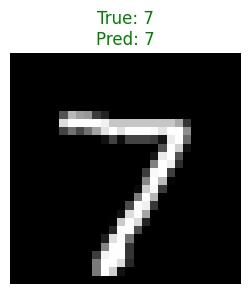

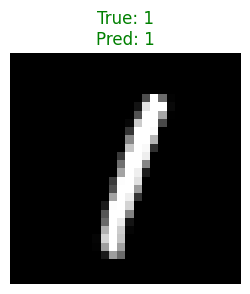

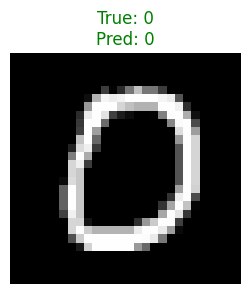


Confusion Matrix (CNN):


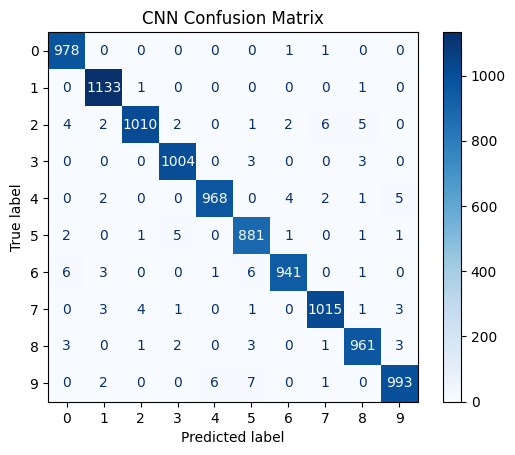

In [8]:
print("\n--- Model Comparison ---")
print(f"ANN Test Accuracy: {accuracy_ann:.4f}")
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")
# Prompt for reflection:
print("\nNotice the difference in accuracy. CNNs typically excel at image tasks because")
print("convolutional layers effectively capture spatial hierarchies and features.")

# Make predictions with the CNN
y_pred_cnn_prob = cnn.predict(X_test_cnn)
y_pred_cnn_classes = np.argmax(y_pred_cnn_prob, axis=1)

# Define the enhanced plotting function
def plot_sample_with_pred(X, y_true, y_pred_classes, index, class_names=None):
    plt.figure(figsize=(3, 3))
    plt.imshow(X[index].reshape(28, 28), cmap='gray') # Reshape back for plotting if needed
    true_label = y_true[index]
    pred_label = y_pred_classes[index]
    title_str = f"True: {true_label}\nPred: {pred_label}"
    if class_names: # If class names list is provided
         title_str = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    color = "green" if true_label == pred_label else "red"
    plt.title(title_str, color=color)
    plt.axis('off')
    plt.show()

print("\n--- Visualizing CNN Predictions (Examples) ---")
# Show prediction for a few test samples
plot_sample_with_pred(X_test, y_test, y_pred_cnn_classes, 0) # Index 0
plot_sample_with_pred(X_test, y_test, y_pred_cnn_classes, 5) # Index 5
plot_sample_with_pred(X_test, y_test, y_pred_cnn_classes, 10) # Index 10

# Display CNN Confusion Matrix
print("\nConfusion Matrix (CNN):")
cm_cnn = confusion_matrix(y_test, y_pred_cnn_classes)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
disp_cnn.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.show()